In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/online_food_delivery_cleaned.csv")


In [3]:
top_customers = (
    df.groupby("Customer_ID")["Final_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers


Customer_ID
CUST4431    52418.0
CUST3471    50989.0
CUST1606    49456.0
CUST8797    47689.0
CUST6252    47495.0
CUST1968    47034.0
CUST9591    46762.0
CUST2910    46190.0
CUST6457    46032.0
CUST1239    45196.0
Name: Final_Amount, dtype: float64

In [4]:
bins = [18, 25, 35, 45, 55, 65]
labels = ["18–25", "26–35", "36–45", "46–55", "56+"]

df["Age_Group"] = pd.cut(df["Customer_Age"], bins=bins, labels=labels)

age_order_value = df.groupby("Age_Group")["Order_Value"].mean()
age_order_value


C:\Users\HP\AppData\Local\Temp\ipykernel_8644\39851541.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_order_value = df.groupby("Age_Group")["Order_Value"].mean()


Age_Group
18–25    2064.048682
26–35    2102.930885
36–45    2079.614286
46–55    2105.718674
56+      2025.347208
Name: Order_Value, dtype: float64

In [5]:
df["Order_Day"].value_counts()


Order_Day
Weekday    71370
Weekend    28630
Name: count, dtype: int64

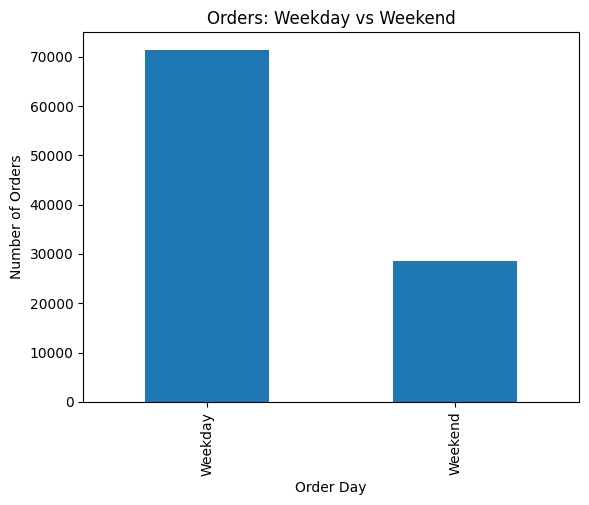

In [6]:
df["Order_Day"].value_counts().plot(kind="bar")
plt.title("Orders: Weekday vs Weekend")
plt.xlabel("Order Day")
plt.ylabel("Number of Orders")
plt.show()


In [7]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)


In [8]:
df["Order_Date"].isna().sum()


np.int64(0)

In [9]:
monthly_revenue = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Final_Amount"]
    .sum()
)

monthly_revenue


Order_Date
2024-01    16008227.0
2024-02    15350442.0
2024-03    15891011.0
2024-04    15466743.0
2024-05    15860508.0
2024-06    15453157.0
2024-07    17914305.0
2024-08    16023871.0
2024-09    15269776.0
2024-10    15678556.0
2024-11    15387419.0
2024-12    15244098.0
Freq: M, Name: Final_Amount, dtype: float64

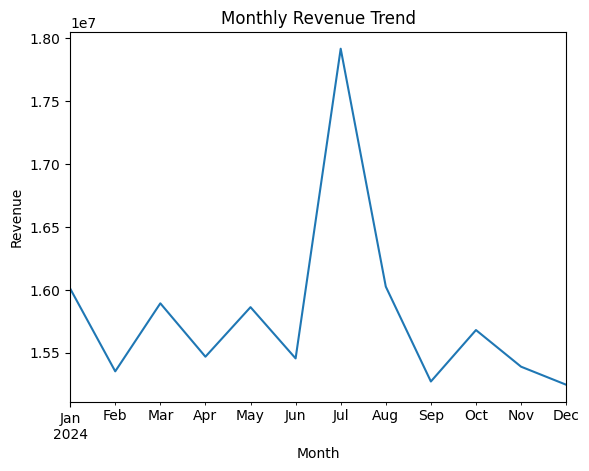

In [10]:
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [11]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_revenue = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Final_Amount"]
    .sum()
)

monthly_revenue


Order_Date
2024-01    16008227.0
2024-02    15350442.0
2024-03    15891011.0
2024-04    15466743.0
2024-05    15860508.0
2024-06    15453157.0
2024-07    17914305.0
2024-08    16023871.0
2024-09    15269776.0
2024-10    15678556.0
2024-11    15387419.0
2024-12    15244098.0
Freq: M, Name: Final_Amount, dtype: float64

In [12]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)


In [13]:
monthly_revenue = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Final_Amount"]
    .sum()
)

monthly_revenue


Order_Date
2024-01    16008227.0
2024-02    15350442.0
2024-03    15891011.0
2024-04    15466743.0
2024-05    15860508.0
2024-06    15453157.0
2024-07    17914305.0
2024-08    16023871.0
2024-09    15269776.0
2024-10    15678556.0
2024-11    15387419.0
2024-12    15244098.0
Freq: M, Name: Final_Amount, dtype: float64

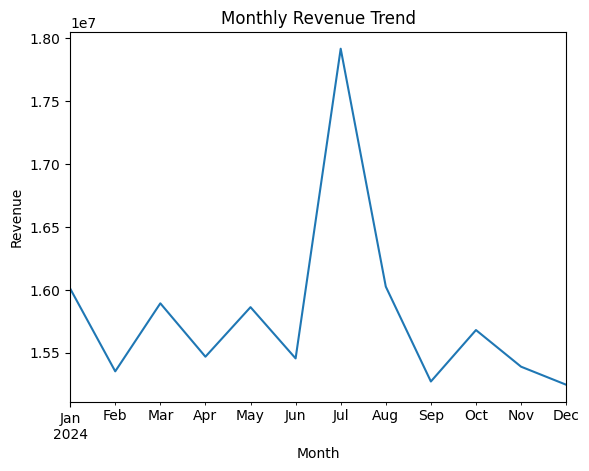

In [14]:
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


In [15]:
df.columns


Index(['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City',
       'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type',
       'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km',
       'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode',
       'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID',
       'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour',
       'Profit_Margin', 'Age_Group'],
      dtype='object')

In [16]:
df["Profit"] = df["Final_Amount"] * (df["Profit_Margin"] / 100)


In [17]:
discount_profit = df.groupby("Discount_Applied")["Profit"].mean()
discount_profit


Discount_Applied
0.0      2.727079
20.0     2.944853
50.0     2.893239
100.0    2.903090
300.0    2.839711
Name: Profit, dtype: float64

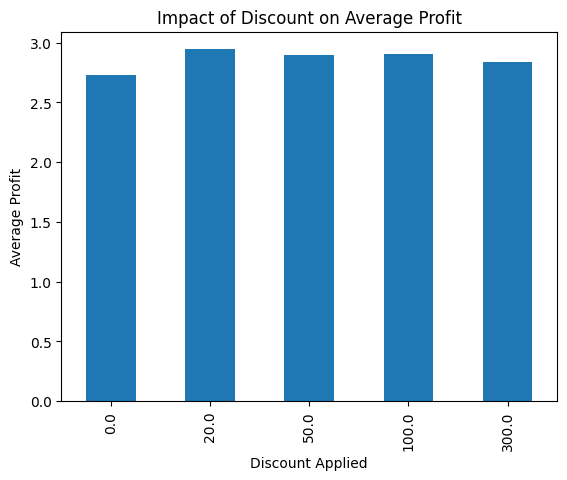

In [18]:
discount_profit.plot(kind="bar")
plt.title("Impact of Discount on Average Profit")
plt.xlabel("Discount Applied")
plt.ylabel("Average Profit")
plt.show()


In [19]:
df.groupby("City")["Final_Amount"].sum().sort_values(ascending=False).head(10)


City
Hyderabad    63687341.0
Bangalore    31820393.0
Delhi        31448023.0
Chennai      31385421.0
Mumbai       31206935.0
Name: Final_Amount, dtype: float64

In [20]:
df.groupby("Cuisine_Type")["Final_Amount"].sum().sort_values(ascending=False)


Cuisine_Type
Indian     63820713.0
Chinese    31576990.0
Arabian    31513101.0
Mexican    31463482.0
Italian    31173827.0
Name: Final_Amount, dtype: float64

In [21]:
df.groupby("Order_Day")["Final_Amount"].sum()


Order_Day
Weekday    135442216.0
Weekend     54105897.0
Name: Final_Amount, dtype: float64

In [22]:
city_revenue = (
    df.groupby("City")["Final_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

city_revenue


City
Hyderabad    63687341.0
Bangalore    31820393.0
Delhi        31448023.0
Chennai      31385421.0
Mumbai       31206935.0
Name: Final_Amount, dtype: float64

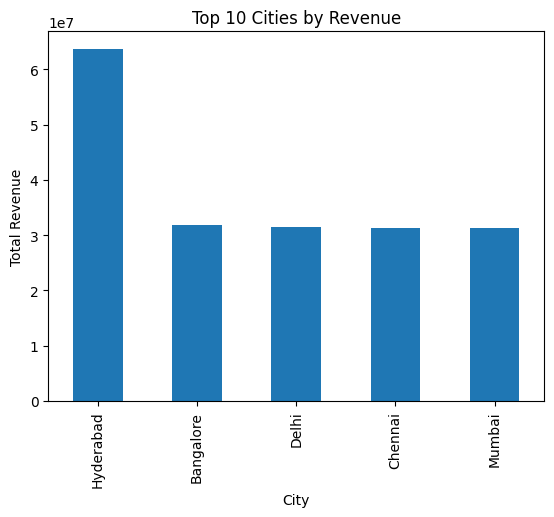

In [23]:
city_revenue.plot(kind="bar")
plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.show()


In [24]:
city_delivery_time = (
    df.groupby("City")["Delivery_Time_Min"]
    .mean()
    .sort_values()
)

city_delivery_time


City
Bangalore    124.346462
Chennai      124.525562
Delhi        124.871578
Hyderabad    125.041446
Mumbai       125.910932
Name: Delivery_Time_Min, dtype: float64

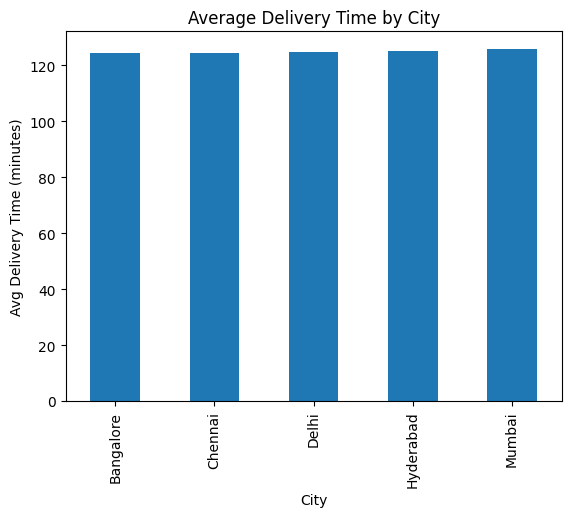

In [25]:
city_delivery_time.plot(kind="bar")
plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Avg Delivery Time (minutes)")
plt.show()


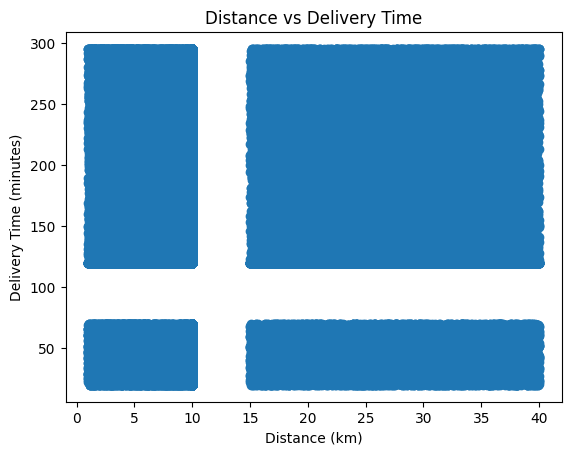

In [26]:
plt.scatter(df["Distance_km"], df["Delivery_Time_Min"])
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()


In [27]:
rating_time = df.groupby("Delivery_Rating")["Delivery_Time_Min"].mean()
rating_time


Delivery_Rating
1.0    125.019521
2.0    124.612784
3.0    124.677944
4.0    125.978922
5.0    125.040837
Name: Delivery_Time_Min, dtype: float64

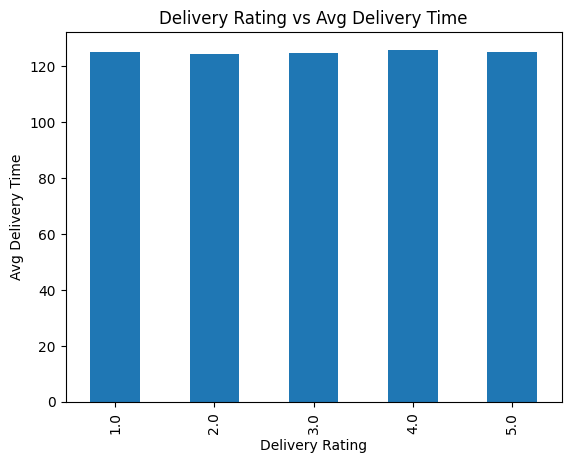

In [28]:
rating_time.plot(kind="bar")
plt.title("Delivery Rating vs Avg Delivery Time")
plt.xlabel("Delivery Rating")
plt.ylabel("Avg Delivery Time")
plt.show()


In [29]:
top_restaurants = (
    df.groupby("Restaurant_Name")["Restaurant_Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_restaurants


Restaurant_Name
Restaurant_101    4.325843
Restaurant_1      4.313472
Restaurant_162    4.308242
Restaurant_496    4.304433
Restaurant_355    4.301657
Restaurant_481    4.300526
Restaurant_209    4.300000
Restaurant_105    4.292019
Restaurant_318    4.292000
Restaurant_392    4.291257
Name: Restaurant_Rating, dtype: float64

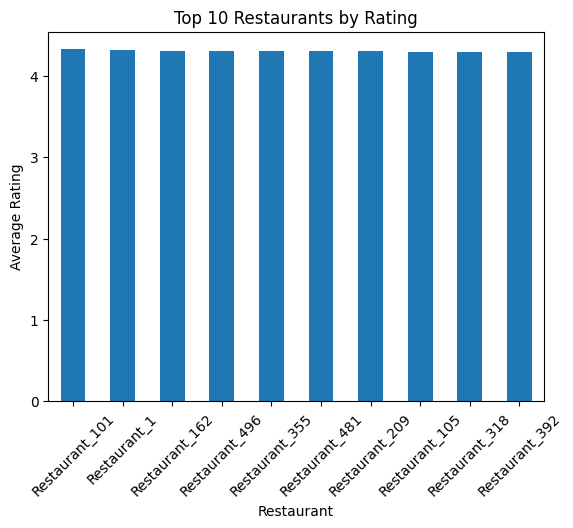

In [30]:
top_restaurants.plot(kind="bar")
plt.title("Top 10 Restaurants by Rating")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()


In [31]:
restaurant_cancel = (
    df.groupby("Restaurant_Name")["Order_Status"]
    .apply(lambda x: (x == "Cancelled").mean() * 100)
    .sort_values(ascending=False)
    .head(10)
)

restaurant_cancel


Restaurant_Name
Restaurant_391    21.938776
Restaurant_390    21.890547
Restaurant_477    21.590909
Restaurant_202    21.568627
Restaurant_373    21.465969
Restaurant_426    21.226415
Restaurant_299    21.134021
Restaurant_455    21.111111
Restaurant_113    20.975610
Restaurant_232    20.903955
Name: Order_Status, dtype: float64

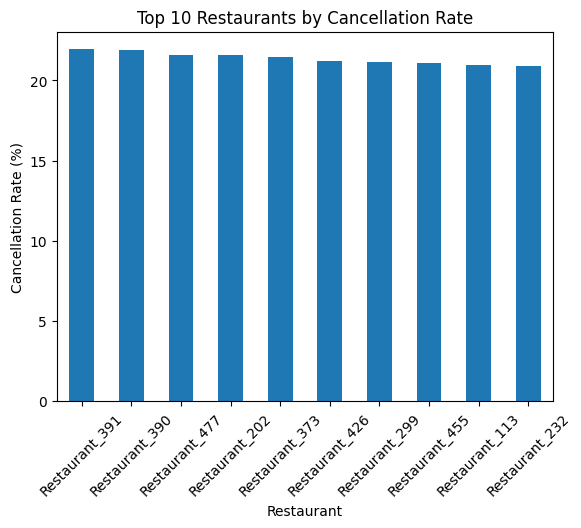

In [32]:
restaurant_cancel.plot(kind="bar")
plt.title("Top 10 Restaurants by Cancellation Rate")
plt.xlabel("Restaurant")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()


In [33]:
cuisine_rating = (
    df.groupby("Cuisine_Type")["Restaurant_Rating"]
    .mean()
    .sort_values(ascending=False)
)

cuisine_rating


Cuisine_Type
Italian    4.210231
Arabian    4.202251
Indian     4.200077
Mexican    4.195519
Chinese    4.190583
Name: Restaurant_Rating, dtype: float64

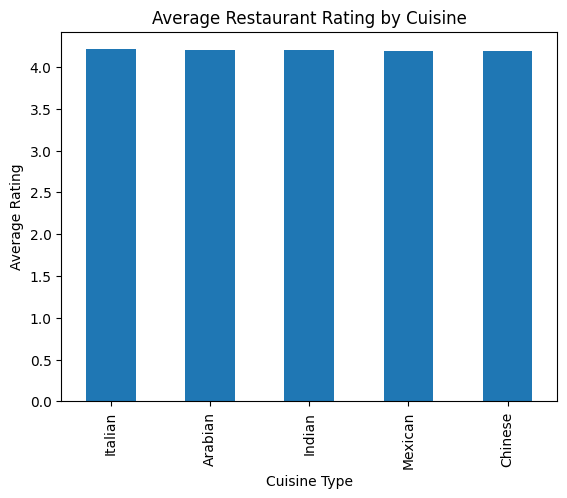

In [34]:
cuisine_rating.plot(kind="bar")
plt.title("Average Restaurant Rating by Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Rating")
plt.show()


In [35]:
cuisine_orders = df["Cuisine_Type"].value_counts()
cuisine_orders


Cuisine_Type
Indian     33570
Arabian    16658
Chinese    16651
Mexican    16602
Italian    16519
Name: count, dtype: int64

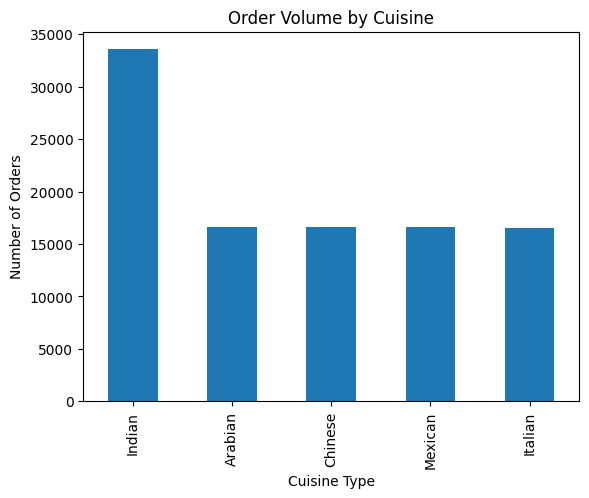

In [36]:
cuisine_orders.plot(kind="bar")
plt.title("Order Volume by Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.show()


In [37]:
peak_orders = df["Peak_Hour"].value_counts()
peak_orders


Peak_Hour
False    33585
True     33453
Name: count, dtype: int64

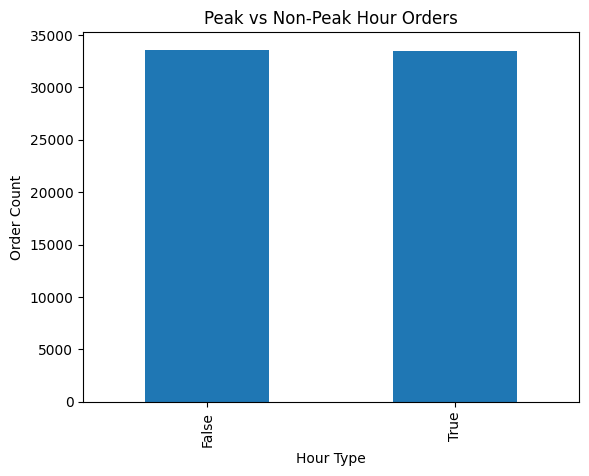

In [38]:
peak_orders.plot(kind="bar")
plt.title("Peak vs Non-Peak Hour Orders")
plt.xlabel("Hour Type")
plt.ylabel("Order Count")
plt.show()


In [39]:
peak_orders = df["Peak_Hour"].value_counts()
peak_orders


Peak_Hour
False    33585
True     33453
Name: count, dtype: int64

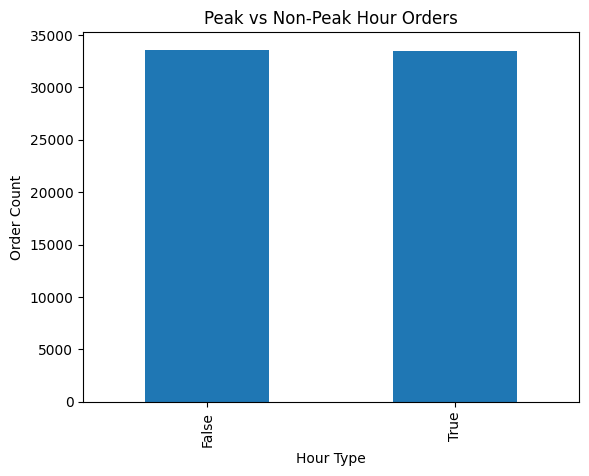

In [40]:
peak_orders.plot(kind="bar")
plt.title("Peak vs Non-Peak Hour Orders")
plt.xlabel("Hour Type")
plt.ylabel("Order Count")
plt.show()


In [41]:
payment_mode = df["Payment_Mode"].value_counts()
payment_mode


Payment_Mode
Card      40005
Wallet    20086
COD       19977
UPI       19932
Name: count, dtype: int64

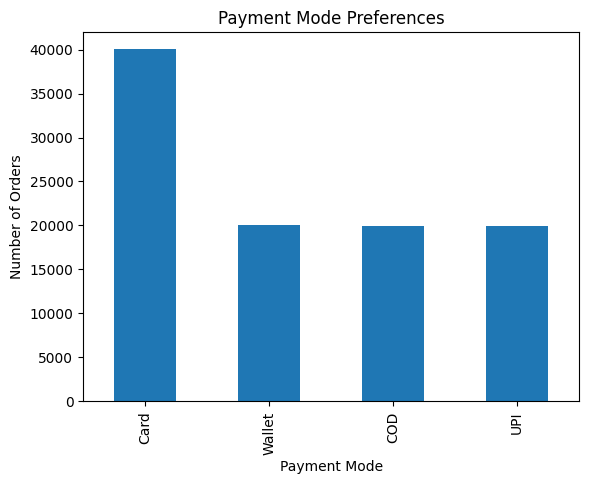

In [42]:
payment_mode.plot(kind="bar")
plt.title("Payment Mode Preferences")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")
plt.show()


In [43]:
cancel_reasons = (
    df[df["Order_Status"] == "Cancelled"]["Cancellation_Reason"]
    .value_counts()
)

cancel_reasons


Cancellation_Reason
Late Delivery         3059
Customer Cancelled    2993
Restaurant Issue      2979
Name: count, dtype: int64

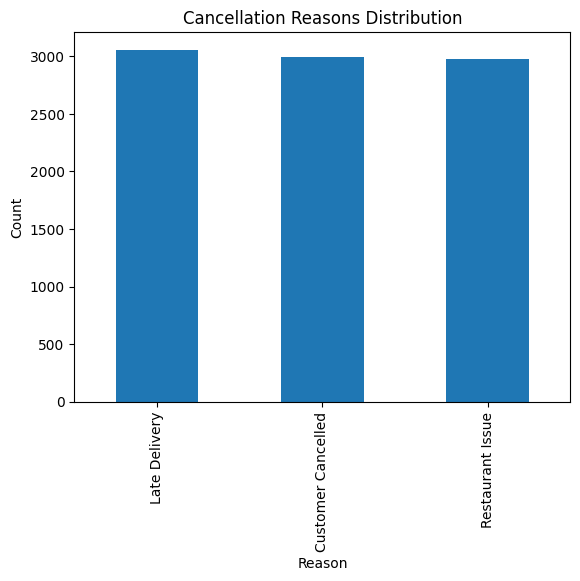

In [44]:
cancel_reasons.plot(kind="bar")
plt.title("Cancellation Reasons Distribution")
plt.xlabel("Reason")
plt.ylabel("Count")
plt.show()
